# Week 3 Session 6: Tuning a CNN + Meet a Transformer

This session has two halves:

1. **Tune the CNN** from Session 5 -- look inside it, then sweep through hyperparameters and see which ones actually move test accuracy.
2. **Meet a different brain** -- the Vision Transformer (ViT). We use a pre-trained ViT from Hugging Face and run it on the same images, head to head with the CNN.

## Activities in this Session

| # | Activity | Topic | Style |
|---|----------|-------|-------|
| 1 | Inside the CNN | Filter & feature-map visualisation | Worked + 1 TODO |
| 2 | Hyperparameter experiments | Kernel size, filter count, pooling, dropout, depth, custom config | Worked + 3 TODOs |
| 3 | A different brain: ViT | Hugging Face image-classification pipeline, CNN vs ViT | Worked + 1 TODO |

> **Heads up:** the first time we load the ViT pipeline Hugging Face will download ~350 MB. Run the install/import cell early.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

# Require GPU training for this notebook run
REQUIRE_GPU = True
gpus = tf.config.list_physical_devices('GPU')

print('TensorFlow version:', tf.__version__)
print('GPU devices:', gpus)

if REQUIRE_GPU and not gpus:
    raise RuntimeError(
        'GPU training requested, but TensorFlow cannot see a GPU. '
        'Restart the notebook kernel after installing tensorflow-metal, '
        'then rerun this cell. Also make sure the selected kernel is mlcourse.'
    )

TRAIN_DEVICE = '/GPU:0' if gpus else '/CPU:0'
print('Training device:', TRAIN_DEVICE)


TensorFlow version: 2.18.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training device: /GPU:0


X_train: (50000, 32, 32, 3)   X_test: (10000, 32, 32, 3)


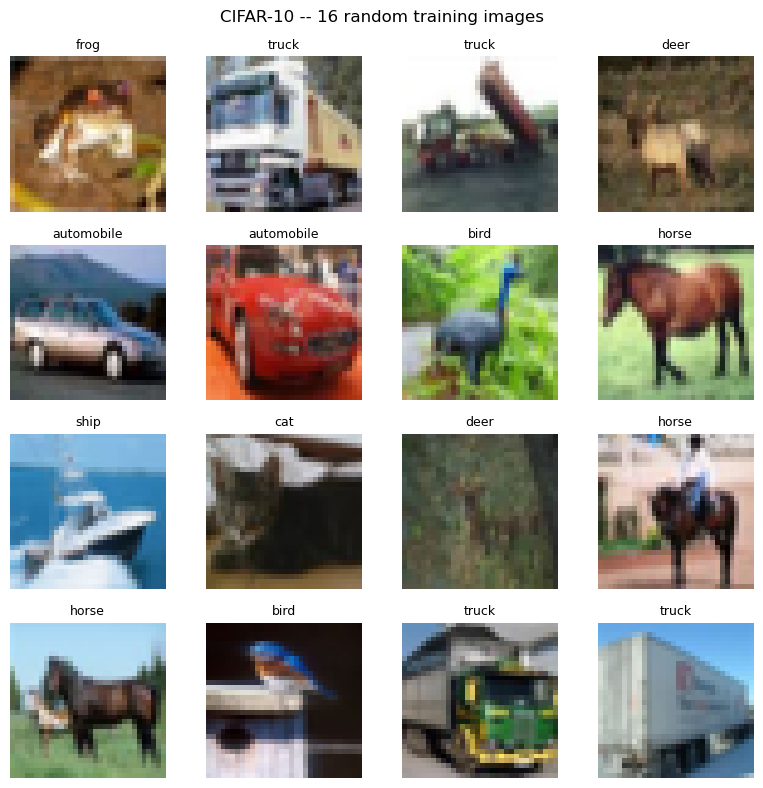

In [2]:

np.random.seed(42)
tf.random.set_seed(42)

# Load the full CIFAR-10 dataset
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()

X_train = X_train_full.astype('float32') / 255.0
X_test  = X_test_full.astype('float32') / 255.0

y_train = y_train_full.flatten()
y_test  = y_test_full.flatten()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')

# Show 16 images in a 4x4 grid with their class labels
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, img, label in zip(axes.flat, X_train[:16], y_train[:16]):
    ax.imshow(img)
    ax.set_title(class_names[label], fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 -- 16 random training images')
plt.tight_layout()
plt.show()

---
# Activity 1 -- Dense NN Baseline on CIFAR-10

In [3]:
# define a simple mode
model_dense = models.Sequential()
model_dense.add(layers.Input(shape=(32, 32, 3)))
model_dense.add(layers.Flatten())
model_dense.add(layers.Dense(128, use_bias=False))
model_dense.add(layers.BatchNormalization())
model_dense.add(layers.Activation('relu'))
model_dense.add(layers.Dropout(0.5))

model_dense.add(layers.Dense(10, activation='softmax'))

model_dense.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

model_dense.summary()

# fit the model to the training data
history_dense = model_dense.fit(X_train, y_train,
                                epochs=10,
                                batch_size=64,
                                validation_data=(X_test, y_test))

# evaluate the model on the test set
test_loss_dense, test_acc_dense = model_dense.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy (Dense): {test_acc_dense:.4f}')

2026-05-17 10:52:01.750254: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-05-17 10:52:01.750288: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-05-17 10:52:01.750292: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1778971921.750311   29359 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1778971921.750337   29359 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395,018 (1.51 MB)

 Trainable params: 394,762 (1.51 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/10


2026-05-17 10:52:02.446743: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.3423 - loss: 1.8845 - val_accuracy: 0.3768 - val_loss: 1.7498
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4016 - loss: 1.6941 - val_accuracy: 0.3939 - val_loss: 1.6907
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4227 - loss: 1.6394 - val_accuracy: 0.4377 - val_loss: 1.6031
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4350 - loss: 1.6084 - val_accuracy: 0.4184 - val_loss: 1.6355
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4451 - loss: 1.5870 - val_accuracy: 0.4000 - val_loss: 1.6888
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4502 - loss: 1.5637 - val_accuracy: 0.4179 - val_loss: 1.6503
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4603 - loss: 1.5421 - val_accuracy: 0.4372 - val_loss: 1.5924
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4620 - loss: 1.5317 - val_accuracy: 0.45

---
# Activity 2 -- Inside the CNN

> ### Activity Card
> **Goal:** Visualise what the CNN actually learned -- the filters in the first conv layer and the feature maps they produce on a real image.
> **Why this matters:** This is the moment a CNN stops being a black box. Filters look like edge / colour / texture detectors. Feature maps show where in the image those patterns live.

In [5]:
# define a simple CNN model
with tf.device(TRAIN_DEVICE):
    model_cnn = models.Sequential()
    model_cnn.add(layers.Input(shape=(32, 32, 3)))

    model_cnn.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model_cnn.add(layers.MaxPooling2D((2, 2)))
    model_cnn.add(layers.Dropout(0.25))

    model_cnn.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model_cnn.add(layers.MaxPooling2D((2, 2)))
    model_cnn.add(layers.Dropout(0.25))

    model_cnn.add(layers.Flatten())
    model_cnn.add(layers.Dense(128, activation='relu'))
    model_cnn.add(layers.Dropout(0.5))

    model_cnn.add(layers.Dense(10, activation='softmax'))

    model_cnn.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

    model_cnn.summary()

    # fit the model to the training data
    history_cnn = model_cnn.fit(X_train, y_train,
                                epochs=10,
                                batch_size=64,
                                validation_data=(X_test, y_test))

    # evaluate the model on the test set
    test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test, y_test, verbose=2)

baseline_acc = test_acc_cnn
print(f'Test accuracy (Baseline CNN): {test_acc_cnn:.4f}')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.3488 - loss: 1.7979 - val_accuracy: 0.5347 - val_loss: 1.3306
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.4830 - loss: 1.4599 - val_accuracy: 0.5775 - val_loss: 1.1969
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5253 - loss: 1.3453 - val_accuracy: 0.6092 - val_loss: 1.1148
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5488 - loss: 1.2853 - val_accuracy: 0.6284 - val_loss: 1.0592
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5585 - loss: 1.2684 - val_accuracy: 0.6438 - val_loss: 1.0291
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5665 - loss: 1.2533 - val_accuracy: 0.6394 - val_loss: 1.0145
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5709 - loss: 1.2420 - val_accuracy: 0.6368 - val_loss: 1.0253
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5749 - loss: 1.2351 - 

---
# Activity 3 -- Simple Vision Transformer on CIFAR-10

This ViT is trained from scratch on the same CIFAR-10 data as the Dense NN and CNN.

The image is split into small patches, each patch becomes a token, and self-attention learns how the patches relate to each other.

### What is a Transformer (in one paragraph)?
A transformer chops the image into small **patches** (here 16x16), turns each patch into a vector, and then asks a single question over and over: *"how much should each patch pay attention to every other patch?"* That mechanism is called **self-attention**, and it replaces convolution entirely.

Important: ViT was pre-trained on ImageNet, so its 1,000 class names are different from CIFAR-10's 10. We will see "tabby cat" instead of "cat", "sports car" instead of "automobile". That is normal -- the goal is to compare top-1 predictions side by side, not class IDs.

In [4]:
# Simple ViT trained on CIFAR-10
class PositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.num_patches = num_patches
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=embed_dim
        )

    def call(self, x):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return x + self.position_embedding(positions)


def build_simple_vit(input_shape=(32, 32, 3), num_classes=10):
    patch_size = 4
    embed_dim = 64
    num_heads = 4
    transformer_blocks = 2
    mlp_dim = 128

    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)

    inputs = layers.Input(shape=input_shape)

    # Convert image patches into tokens
    x = layers.Conv2D(
        filters=embed_dim,
        kernel_size=patch_size,
        strides=patch_size,
        padding='valid'
    )(inputs)

    x = layers.Reshape((num_patches, embed_dim))(x)
    x = PositionEmbedding(num_patches, embed_dim)(x)

    # Transformer encoder blocks
    for _ in range(transformer_blocks):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=0.1
        )(x1, x1)

        x = layers.Add()([x, attention])

        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        x1 = layers.Dense(mlp_dim, activation='gelu')(x1)
        x1 = layers.Dropout(0.1)(x1)
        x1 = layers.Dense(embed_dim)(x1)

        x = layers.Add()([x, x1])

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='simple_vit_cifar10')


with tf.device(TRAIN_DEVICE):
    model_vit = build_simple_vit()

    model_vit.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model_vit.summary()

    history_vit = model_vit.fit(
        X_train, y_train,
        epochs=10,
        batch_size=64,
        validation_data=(X_test, y_test)
    )

    test_loss_vit, test_acc_vit = model_vit.evaluate(X_test, y_test, verbose=2)

print(f'Test accuracy (Simple ViT): {test_acc_vit:.4f}')

Model: "simple_vit_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 64)  │      3,136 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 64)    │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, 64, 64)    │      4,096 │ reshape[0][0]     │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ position_embeddi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ position_embeddi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64)    │          0 │ add_1[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 128)   │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 79,114 (309.04 KB)

 Trainable params: 79,114 (309.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1750 - loss: 2.5755 - val_accuracy: 0.2960 - val_loss: 1.8775
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.2523 - loss: 2.1408 - val_accuracy: 0.3636 - val_loss: 1.7016
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.3329 - loss: 1.8454 - val_accuracy: 0.4213 - val_loss: 1.5605
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.3966 - loss: 1.6649 - val_accuracy: 0.4553 - val_loss: 1.4901
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.4359 - loss: 1.5563 - val_accuracy: 0.4820 - val_loss: 1.4287
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.4620 - loss: 1.4948 - val_accuracy: 0.4917 - val_loss: 1.3866
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.4801 - loss: 1.4453 - val_accuracy: 0.5074 - val_loss: 1.3507
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.4945 - loss: 1.4147 - 

---
# Activity 4 -- Pre-trained ViT on CIFAR-10 Images

Now we use a pre-trained Vision Transformer from Hugging Face.

Important: this model was trained on ImageNet, not CIFAR-10. So it predicts labels like `tabby cat`, `sports car`, or `airliner` instead of the exact CIFAR-10 labels. We use it for comparison on the same test images, not for a direct CIFAR-10 accuracy score.

In [7]:
# Pre-trained ViT from Hugging Face
from transformers import pipeline
from PIL import Image

vit_pretrained = pipeline(
    task='image-classification',
    model='google/vit-base-patch16-224',
    framework='pt',
    device=0,
    top_k=3
)

print('Pre-trained ViT ready.')

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use mps:0


Pre-trained ViT ready.


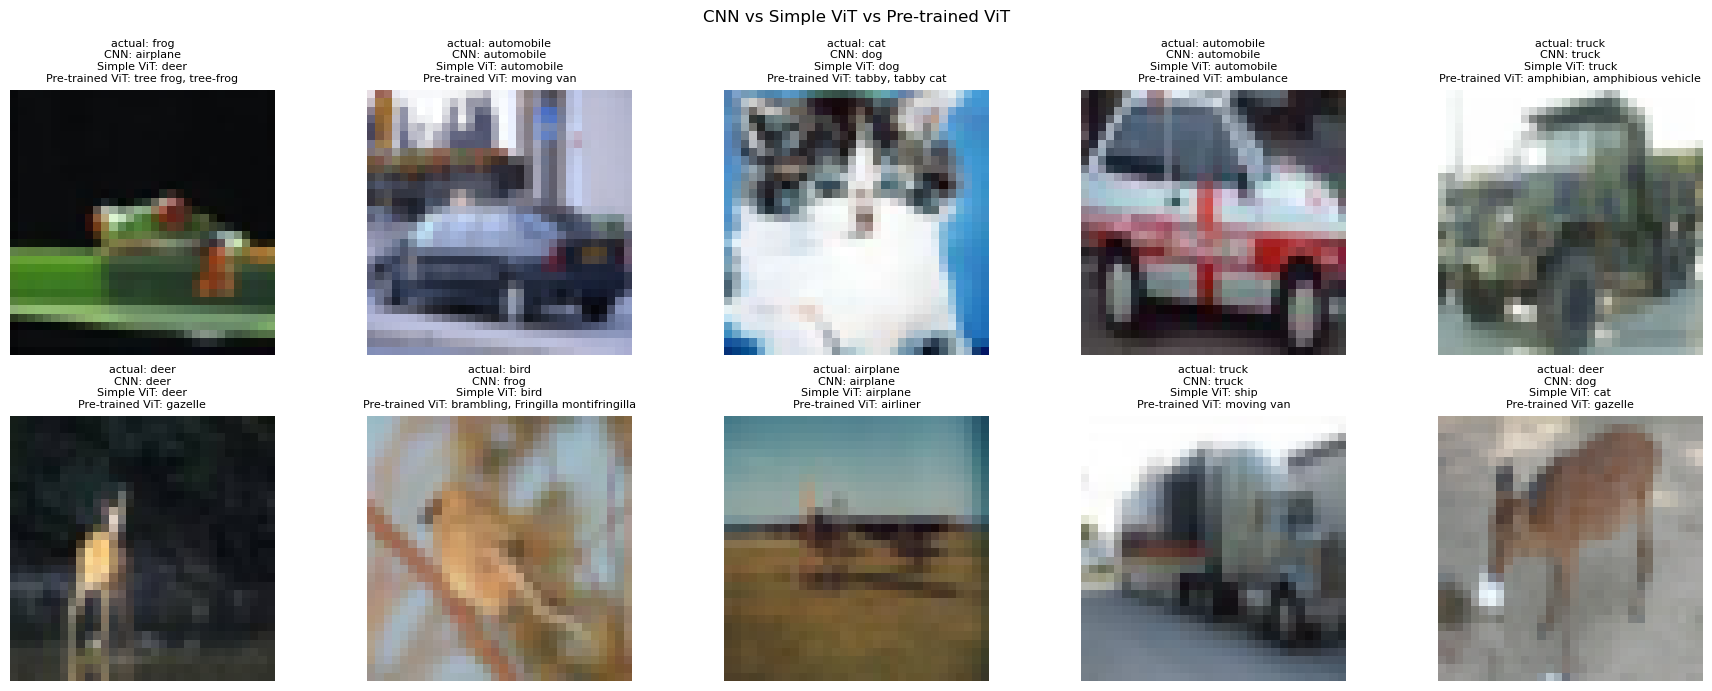

In [13]:
# Test the pre-trained ViT on random CIFAR-10 images
num_examples = 10

rng = np.random.default_rng()
sample_indices = rng.choice(len(X_test), size=num_examples, replace=False)

pretrained_vit_predictions = []

for idx in sample_indices:
    img = (X_test[idx] * 255).astype('uint8')
    pil_img = Image.fromarray(img).resize((224, 224))

    preds = vit_pretrained(pil_img)
    pretrained_vit_predictions.append(preds)

# CNN predictions on the same images
cnn_probs = model_cnn.predict(X_test[sample_indices], verbose=0)
cnn_top1 = cnn_probs.argmax(axis=1)

# Simple ViT predictions on the same images
vit_probs = model_vit.predict(X_test[sample_indices], verbose=0)
vit_top1 = vit_probs.argmax(axis=1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for ax, idx, cnn_idx, vit_idx, pretrained_preds in zip(
    axes.flat,
    sample_indices,
    cnn_top1,
    vit_top1,
    pretrained_vit_predictions
):
    actual = class_names[y_test[idx]]
    cnn_label = class_names[cnn_idx]
    simple_vit_label = class_names[vit_idx]
    pretrained_label = pretrained_preds[0]['label']

    ax.imshow(X_test[idx])
    ax.set_title(
        f'actual: {actual}\n'
        f'CNN: {cnn_label}\n'
        f'Simple ViT: {simple_vit_label}\n'
        f'Pre-trained ViT: {pretrained_label}',
        fontsize=8
    )
    ax.axis('off')

plt.suptitle('CNN vs Simple ViT vs Pre-trained ViT')
plt.tight_layout()
plt.show()

In [9]:
for idx, preds in zip(sample_indices, pretrained_vit_predictions):
    print(f'\nImage index: {idx}')
    print(f'Actual CIFAR-10 label: {class_names[y_test[idx]]}')

    for rank, pred in enumerate(preds, start=1):
        print(f"{rank}. {pred['label']}  ({pred['score']:.3f})")


Image index: 0
Actual CIFAR-10 label: cat
1. tabby, tabby cat  (0.254)
2. Egyptian cat  (0.156)
3. tiger cat  (0.057)

Image index: 1
Actual CIFAR-10 label: ship
1. speedboat  (0.633)
2. container ship, containership, container vessel  (0.046)
3. trimaran  (0.037)

Image index: 2
Actual CIFAR-10 label: ship
1. analog clock  (0.166)
2. speedboat  (0.162)
3. magnetic compass  (0.100)

Image index: 3
Actual CIFAR-10 label: airplane
1. book jacket, dust cover, dust jacket, dust wrapper  (0.385)
2. web site, website, internet site, site  (0.089)
3. cassette  (0.065)

Image index: 4
Actual CIFAR-10 label: frog
1. tailed frog, bell toad, ribbed toad, tailed toad, Ascaphus trui  (0.969)
2. tree frog, tree-frog  (0.011)
3. bullfrog, Rana catesbeiana  (0.007)


This is only an approximate accuracy because the pretrained ViT predicts ImageNet classes, not CIFAR-10 classes. We manually map labels like "tabby cat" to "cat" and "sports car" to "automobile". A true CIFAR-10 accuracy would require fine-tuning the ViT on CIFAR-10.

In [10]:
def map_imagenet_to_cifar(label):
    label = label.lower()

    if any(word in label for word in ['airliner', 'warplane', 'airship', 'plane']):
        return 'airplane'

    if any(word in label for word in ['car', 'cab', 'limousine', 'jeep', 'convertible', 'racer']):
        return 'automobile'

    if any(word in label for word in ['bird', 'hen', 'cock', 'ostrich', 'eagle', 'owl', 'jay', 'magpie', 'robin', 'finch']):
        return 'bird'

    if any(word in label for word in ['cat', 'tabby', 'tiger cat', 'persian']):
        return 'cat'

    if any(word in label for word in ['deer', 'stag', 'buck']):
        return 'deer'

    if any(word in label for word in ['dog', 'hound', 'terrier', 'retriever', 'shepherd', 'poodle', 'chihuahua']):
        return 'dog'

    if any(word in label for word in ['frog', 'toad']):
        return 'frog'

    if any(word in label for word in ['horse', 'zebra']):
        return 'horse'

    if any(word in label for word in ['ship', 'boat', 'liner', 'canoe', 'yawl', 'speedboat']):
        return 'ship'

    if any(word in label for word in ['truck', 'lorry', 'van', 'pickup', 'fire engine', 'garbage truck']):
        return 'truck'

    return 'unknown'

In [12]:
num_images = 2000

correct = 0
known = 0

for idx in range(num_images):
    img = (X_test[idx] * 255).astype('uint8')
    pil_img = Image.fromarray(img).resize((224, 224))

    pred = vit_pretrained(pil_img)[0]
    imagenet_label = pred['label']

    predicted_cifar = map_imagenet_to_cifar(imagenet_label)
    actual_cifar = class_names[y_test[idx]]

    if predicted_cifar != 'unknown':
        known += 1
        if predicted_cifar == actual_cifar:
            correct += 1

accuracy = correct / known

print(f'Images tested: {num_images}')
print(f'Images mapped to CIFAR-10 labels: {known}')
print(f'Approximate pretrained ViT accuracy: {accuracy:.4f}')

Images tested: 2000
Images mapped to CIFAR-10 labels: 1059
Approximate pretrained ViT accuracy: 0.8914
